# Pytroch Titanic

In [1]:
import sys
import os
import torch

print(os.getcwd())
sys.path.append('../ml/clean-code')

from day4_titanic_cleaning import load_data, clean_data, encoding
from titanic_logistic_regression import train_test_split_data



c:\Users\Edward\daily-ds\deep-learning


In [2]:
from sklearn.preprocessing import StandardScaler


df = load_data('../ml/data/train.csv')
df = clean_data(df)
df = encoding(df)
X_train, X_test, y_train, y_test = train_test_split_data(df, 0.2)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train_scaled, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).reshape(-1, 1)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).reshape(-1, 1)
print(X_train_tensor.shape)
print(y_train_tensor.shape)
#print(X_test_tensor)
#print(y_test_tensor)

torch.Size([711, 9])
torch.Size([711, 1])


In [3]:
from torch.utils.data import TensorDataset, DataLoader

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle =True)
# shuffle=True: reorders data each epoch, prevents learning row-order artifacts

for X_batch, y_batch in train_loader:
    print(X_batch.shape, y_batch.shape)


torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([32, 9]) torch.Size([32, 1])
torch.Size([7, 9]) torch.Size([7, 1])


In [4]:
import torch.nn as nn

model = nn.Sequential(
    nn.Linear(in_features=9, out_features=16),
    nn.Sigmoid(),
    nn.Linear(in_features=16, out_features=8),
    nn.Sigmoid(),
    nn.Linear(in_features=8, out_features=1),
    nn.Sigmoid()
)

loss_fn = torch.nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [5]:
for epoch in range(20):
    for X_batch, y_batch in train_loader:    # 23 batches (22x32 + 1x7)
        prediction = model(X_batch)   # [32,1] — 32 PER-ROW preds, not 1
        loss = loss_fn(prediction, y_batch)   # BCELoss AVERAGES the 32 into 1 number

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    print(f"Epoch {epoch}, Loss: {loss.item()}") # last BATCH's loss, not epoch average
    
# BATCH-TO-BATCH WEIGHT CHAIN: Batch 1 updates ALL weights once (via
# backward+step). Batch 2 then runs through the network using THOSE
# just-updated weights, not a fresh/random start — producing its own
# update, which Batch 3 then builds on, and so on. Weights never reset
# between batches or between epochs — it's one continuous chain:
# W0 -> Batch1 -> W1 -> Batch2 -> W2 -> ... -> end of epoch -> next
# epoch continues from wherever the last epoch left off

Epoch 0, Loss: 0.7594515085220337
Epoch 1, Loss: 0.5386570692062378
Epoch 2, Loss: 0.5012056231498718
Epoch 3, Loss: 0.5074759125709534
Epoch 4, Loss: 0.3337706923484802
Epoch 5, Loss: 0.5068853497505188
Epoch 6, Loss: 0.15637241303920746
Epoch 7, Loss: 0.15195681154727936
Epoch 8, Loss: 0.39852291345596313
Epoch 9, Loss: 0.31730765104293823
Epoch 10, Loss: 0.2196020781993866
Epoch 11, Loss: 0.5840345025062561
Epoch 12, Loss: 0.250996857881546
Epoch 13, Loss: 0.3827067017555237
Epoch 14, Loss: 0.7721575498580933
Epoch 15, Loss: 0.13569830358028412
Epoch 16, Loss: 0.1254429668188095
Epoch 17, Loss: 0.22370536625385284
Epoch 18, Loss: 0.27507108449935913
Epoch 19, Loss: 0.3574923574924469


# Evaluation

In [6]:
model.eval()

# separate full-dataset pass — training loop never stores all preds, they're overwritten every batch
with torch.no_grad():
    train_predictions = model(X_train_tensor)
    test_predictions = model(X_test_tensor)

print(train_predictions.shape)
print(train_predictions[:10])

train_pred_classes = (train_predictions >= 0.5).float()
test_pred_classes = (test_predictions >= 0.5).float()

train_accuracy = (train_pred_classes == y_train_tensor).float().mean()
test_accuracy = (test_pred_classes == y_test_tensor).float().mean()

print(f"Train accuracy: {train_accuracy.item()}")
print(f"Test accuracy: {test_accuracy.item()}")


torch.Size([711, 1])
tensor([[0.3680],
        [0.1351],
        [0.3826],
        [0.9700],
        [0.3358],
        [0.1160],
        [0.9642],
        [0.3575],
        [0.6860],
        [0.3710]])
Train accuracy: 0.8284106850624084
Test accuracy: 0.8033707737922668


# Tensorflow Titanic

In [7]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

keras.utils.set_random_seed(42)
tf.keras.backend.clear_session()

model_tf = Sequential([
    layers.Dense(units = 16, activation = 'sigmoid'),
    layers.Dense(units = 8, activation = 'sigmoid'),
    layers.Dense(units = 1, activation = 'sigmoid')
])

model_tf.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy', # 'mean' reduction is the DEFAULT here too —
    # averages all 32 rows' errors into 1 loss number, same as PyTorch's
    # BCELoss(reduction='mean') default — built into the loss fn, not manual
    metrics = ['accuracy']  # auto-tracks accuracy, no manual calc needed
)

# same mechanism as PyTorch
history = model_tf.fit(
    X_train_scaled, y_train, # plain NumPy/pandas — NO manual torch.tensor()
    epochs = 20,
    batch_size = 32,
    validation_data = (X_test_scaled, y_test)
)
# .fit() = the ENTIRE nested epoch/batch loop, automated internally.
# No visible .backward()/.step()/.zero_grad() because Keras does all of
# that hidden inside this one call — same mechanism

print(history)
# EARLY FLAT ACCURACY (~0.618, epochs 1-7): model was predicting "died" for
# almost every passenger — matches Titanic's raw data actual death rate (~62%), the
# lazy majority-class baseline. Weights hadn't yet learned to use real
# features (Sex, Pclass) to differentiate. Once they did, accuracy climbed.


Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - accuracy: 0.6174 - loss: 0.6630 - val_accuracy: 0.6180 - val_loss: 0.6577
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6174 - loss: 0.6542 - val_accuracy: 0.6180 - val_loss: 0.6508
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6174 - loss: 0.6471 - val_accuracy: 0.6180 - val_loss: 0.6447
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6174 - loss: 0.6403 - val_accuracy: 0.6180 - val_loss: 0.6386
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6174 - loss: 0.6333 - val_accuracy: 0.6180 - val_loss: 0.6320
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6174 - loss: 0.6258 - val_accuracy: 0.6180 - val_loss: 0.6250
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6174 - loss: 0.6178 - val_accuracy: 0.6180 - val_loss: 0.6174
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6217 - loss: 0.6093 - val_accuracy: 0.6124 - val_los

## Tensorflow plot

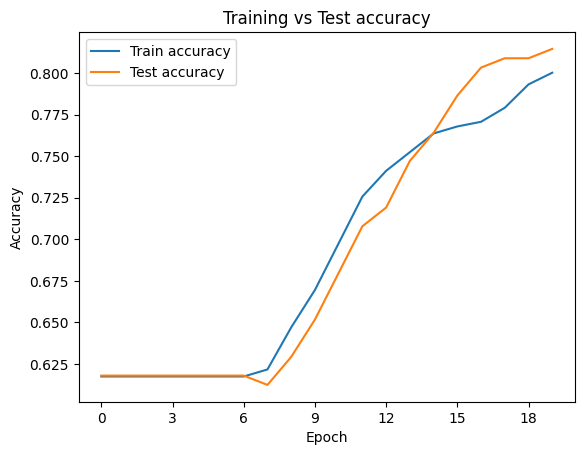

In [8]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Test accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Test accuracy')
plt.legend()
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.show()

## Prevent Overfitting Ways
### Early Stopping (patience)

In [14]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

model_tf_v2 = Sequential([
    layers.Dense(units=16, activation='sigmoid'),
    layers.Dense(units=8, activation='sigmoid'),
    layers.Dense(units=1, activation='sigmoid')
])
model_tf_v2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_2 = model_tf_v2.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop]
)

print(history_2)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.3826 - loss: 0.8230 - val_accuracy: 0.3820 - val_loss: 0.7822
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3826 - loss: 0.7626 - val_accuracy: 0.3820 - val_loss: 0.7332
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3812 - loss: 0.7207 - val_accuracy: 0.4045 - val_loss: 0.7005
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4880 - loss: 0.6926 - val_accuracy: 0.6629 - val_loss: 0.6789
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6217 - loss: 0.6739 - val_accuracy: 0.6180 - val_loss: 0.6645
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6174 - loss: 0.6611 - val_accuracy: 0.6180 - val_loss: 0.6545
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6174 - loss: 0.6518 - val_accuracy: 0.6180 - val_loss: 0.6470
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6174 - loss: 0.6446 - val_accuracy: 0.6180 - 

## Looking at the best weights 

In [15]:
print(f"Training stopped after {len(history_2.history['loss'])} epochs")
print(f"Best val_loss achieved: {min(history_2.history['val_loss'])}")

Training stopped after 81 epochs
Best val_loss achieved: 0.43888163566589355


## Dropout

In [ ]:
model_tf_dropout = Sequential([
    layers.Dense(units=16, activation='sigmoid'),
    layers.Dropout(0.2),# randomly zeroes ~20% of neurons EACH BATCH during
    # training only — forces network to not over-rely on specific neurons.
    # Fully OFF during prediction/eval — all neurons active then
    layers.Dense(units=8, activation='sigmoid'),
    layers.Dropout(0.2),
    layers.Dense(units=1, activation='sigmoid')
])

model_tf_dropout.compile(
    optimizer='adam',
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

history_dropout = model_tf_dropout.fit(
    X_train_scaled, y_train,
    epochs=100,
    batch_size=32,
    validation_data=(X_test_scaled, y_test),
    callbacks=[early_stop]
)

print(history_dropout)
# RESULT: ran full 100 epochs (early stopping never triggered — dropout's
# randomness makes val_loss noisier, never stayed flat long enough for
# patience=5 to trigger)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.4937 - loss: 0.7077 - val_accuracy: 0.6067 - val_loss: 0.6884
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5302 - loss: 0.6929 - val_accuracy: 0.6180 - val_loss: 0.6746
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5921 - loss: 0.6745 - val_accuracy: 0.6180 - val_loss: 0.6667
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5921 - loss: 0.6759 - val_accuracy: 0.6180 - val_loss: 0.6617
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6231 - loss: 0.6676 - val_accuracy: 0.6180 - val_loss: 0.6579
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6160 - loss: 0.6576 - val_accuracy: 0.6180 - val_loss: 0.6546
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6174 - loss: 0.6592 - val_accuracy: 0.6180 - val_loss: 0.6514
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6034 - loss: 0.6606 - val_accuracy: 0.6180 - 